In [23]:
import librosa # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
from sklearn.preprocessing import LabelEncoder # type: ignore
import pickle
from scipy.signal import butter, lfilter # type: ignore
import noisereduce as nr # type: ignore
from IPython.display import Audio # type: ignore

In [14]:
# Sample rate and desired cutoff frequencies (in Hz).
order = 4
lowcut = 200.0
highcut = 1200.0

# Filter Function 
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y


In [15]:
# Encoding targets
labels = ['Drone','No_Drone']           # define lables
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

print("#: Encoding targets")
print("labels:")
print(labels)

#: Encoding targets
labels:
['Drone', 'No_Drone']


In [16]:
# Load ML classification model as a pickle file
print("Load ML classification model as a pickle file")
model_pkl_file = "/Users/panya/Project-ALL/DroneClassification/AcousticDroneDetection/model/2024-09-18 02:58:25.788779.pkl"
with open(model_pkl_file, 'rb') as file:  
    model = pickle.load(file)

Load ML classification model as a pickle file


In [17]:
import pyaudio
import wave
import datetime
from pvrecorder import PvRecorder

# Find Available Microphones
print("Avalible Audio Input")
devices = PvRecorder.get_available_devices()
for device_index in range(len(devices)):
    print(f"CH[{device_index}] : {devices[device_index]}")  

Avalible Audio Input
CH[0] : Panya-iPhone Microphone
CH[1] : USB Audio
CH[2] : HyperX SoloCast
CH[3] : C922 Pro Stream Webcam
CH[4] : MacBook Air Microphone
CH[5] : Microsoft Teams Audio
CH[6] : ZoomAudioDevice


In [19]:
chunk = 1024  # Record in chunks of 1024 samples
sample_format = pyaudio.paInt16  # 16 bits per sample
channels = 2
fs = 44100  # Record at 44100 samples per second
seconds = 4

p = pyaudio.PyAudio()  # Create an interface to PortAudio

print('audio capture')
stream = p.open(format=sample_format,
                channels=channels,
                rate=fs,
                frames_per_buffer=chunk,
                input=True)

frames = []  # Initialize array to store frames

# Store data in chunks for 3 seconds
for i in range(0, int(fs / chunk * seconds)):
    data = stream.read(chunk)
    frames.append(data)

# Stop and close the stream 
stream.stop_stream()
stream.close()
# Terminate the PortAudio interface
p.terminate()

print('Finished capture')

audio capture
Finished capture


In [20]:
# Save the recorded data as a WAV file
WaveFileName = "AudioOutput/audio.wav"  
wf = wave.open(WaveFileName, 'wb')
wf.setnchannels(channels)
wf.setsampwidth(p.get_sample_size(sample_format))
wf.setframerate(fs)
wf.writeframes(b''.join(frames))
wf.close()

File Audio Test: AudioOutput/audio.wav
Output Predic: No_Drone


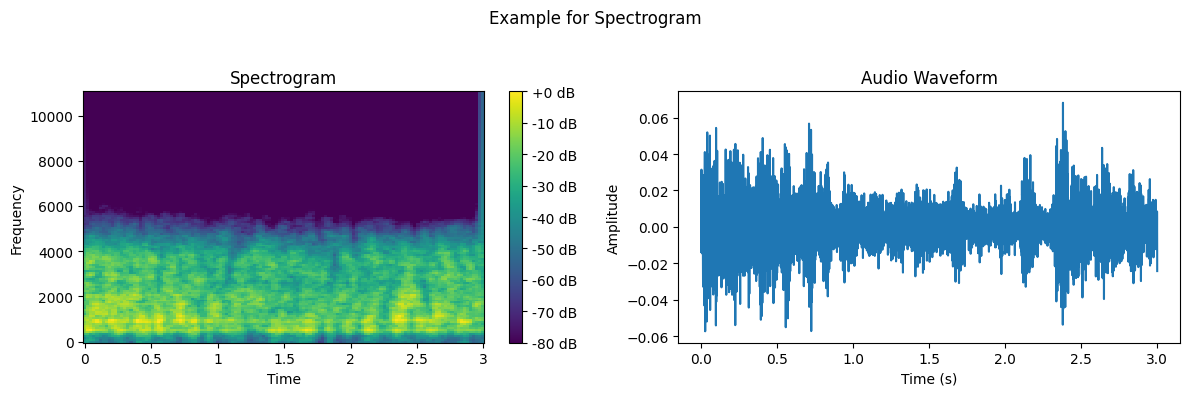

In [25]:
audio_path = WaveFileName
#print("File Audio Test: " + audio_path)
#audio_path = "/Users/panya/Project-ALL/DroneClassification/AcousticDroneDetection/TestAudio/No_Drone/Natural_3-14-ex57.wav"
audio_test, sample_rate = librosa.load(audio_path, duration=3)  # Load audio and limit to 3 seconds

# normalize audio  
max_value = np.max(np.abs(audio_test))       # Determine the maximum values
audio_normalize = audio_test/max_value        # Use max_value and normalize sound data to get values between -1 & +1

# band pass filter 
audio_BPF = butter_bandpass_filter(audio_normalize,lowcut,highcut,sample_rate,order=7)

# Noise reduce
Audio_Reduced_Noise = nr.reduce_noise(y=audio_BPF, sr=sample_rate,prop_decrease = 1)

# convert to spectrogram 
spectrogram = librosa.feature.melspectrogram(y=Audio_Reduced_Noise, sr=sample_rate)
spectrogram = librosa.power_to_db(spectrogram, ref=np.max)

# test model
Y_Test =  spectrogram.T.reshape(-1,1)
OutputPredic = model.predict(Y_Test.T)
OutputLabel = label_encoder.inverse_transform(OutputPredic)
print(f'Output Predic: {OutputLabel[0]}')

# Plot Spectrogram
plt.figure(figsize=(12, 4))
plt.suptitle(f'Example for Spectrogram')
plt.subplot(1, 2, 1)
plt.title(f'Spectrogram')
librosa.display.specshow(spectrogram, x_axis='time', y_axis='hz',cmap='viridis')  #cmap = 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
plt.colorbar(format='%+2.0f dB')
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.title(f'Audio Waveform')
plt.plot(np.linspace(0, len(Audio_Reduced_Noise) / sample_rate, len(Audio_Reduced_Noise)), Audio_Reduced_Noise)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Audio(data=audio_test, rate=sample_rate)
